## 메모리 기능이 추가된 금융 고객센터 챗봇

이 Practice는 금융 고객센터 상담 시나리오를 다룹니다. 고객이 자신의 금융 개인정보(예: 이름, 계좌번호 등)를 입력하고, `remember` 라는 키워드로 "기억"을 요청합니다. 이후 다른 상담 스레드(다른 thread_id)에서 동일한 고객(user_id)이 다시 질문하면, 이전에 저장된 메모리를 바탕으로 불필요한 재질문 없이 자연스럽게 응대하는 챗봇을 구현합니다.

### 목표
- 메시지 상태(`MessagesState`)를 사용하는 LangGraph 노드를 구성합니다.
- 사용자별 메모리를 저장/검색하기 위한 Store와 Checkpointer를 구성합니다.
- `remember` 키워드가 포함된 입력을 자동 추출하여 메모리에 저장합니다.
- 서로 다른 thread에서 동일한 user_id로 상담 시, 저장된 메모리를 활용해 응답 품질을 높입니다.

### 조건
- LLM 모델: `gpt-4.1` (온도 0)
- 메모리 저장: `user_id` 기반 네임스페이스로 구분
- 키 포인트: `remember` 가 포함된 입력이면 메모리 추출 → 저장, 이후 대화에 반영

---

아래 각 소파트에는
- 실습 코드: 스스로 채워 넣는 TODO 형태
- 정답 코드: 참고용 구현
이 함께 제공됩니다. 우선 실습 코드를 시도해 본 뒤, 정답 코드를 참고하세요.


In [1]:
# 공통 준비 코드 (실행)
from dotenv import load_dotenv
from langchain_teddynote import logging

load_dotenv(override=True)
logging.langsmith("LangGraph-Memory-Finance-CC-Practice")

LangSmith 추적을 시작합니다.
[프로젝트명]
LangGraph-Memory-Finance-CC-Practice


### 1) LLM과 메모리 추출기 준비

금융 고객센터 시나리오에 사용할 LLM과 간단한 메모리 추출기를 준비합니다. 추출기는 `remember` 키워드가 포함된 메시지에서 개인정보(예: 이름, 계좌번호, 생년월일 등)를 구조화해 저장하기 위함입니다.

요구사항
- `ChatOpenAI`로 `gpt-4.1`, `temperature=0` 모델을 생성하세요.
- `create_memory_extractor(model="gpt-4.1")` 와 유사한 인터페이스의 추출기를 준비한다고 가정하고, 변수를 선언하세요.


### `create_memory_extractor` 구조

```python
# Pydantic 모델 정의
class MemoryItem(BaseModel):
    """개별 메모리 아이템"""

    key: str = Field(description="메모리 키 (예: user_name, preference, fact)")
    value: str = Field(description="메모리 값")
    category: str = Field(
        description="카테고리 (personal_info, preference, interest, relationship, fact, etc.)"
    )
    importance: int = Field(description="중요도 (1-5, 5가 가장 중요)", ge=1, le=5)
    confidence: float = Field(description="추출 신뢰도 (0.0-1.0)", ge=0.0, le=1.0)


class ExtractedMemories(BaseModel):
    """추출된 메모리 컬렉션"""

    memories: List[MemoryItem] = Field(description="추출된 메모리 아이템 리스트")
    summary: str = Field(description="대화 내용 요약")
    timestamp: str = Field(
        default_factory=lambda: datetime.now().isoformat(), description="추출 시간"
    )

    # Output Parser 생성
    memory_parser = PydanticOutputParser(pydantic_object=ExtractedMemories)
    
    # 시스템 프롬프트 설정
    if system_prompt is None:
        system_prompt = DEFAULT_SYSTEM_PROMPT
    
    # 전체 프롬프트 템플릿 구성
    template = f"""{system_prompt}

User Input: {{input}}

{{format_instructions}}
...
"""
    
    # 프롬프트 생성
    prompt = ChatPromptTemplate.from_template(
        template,
        partial_variables={"format_instructions": memory_parser.get_format_instructions()},
    )
    
    # 모델 설정
    model = ChatOpenAI(model="gpt-4.1", temperature=0)
    
    # 메모리 추출 체인 생성
    memory_extractor = prompt | model | memory_parser
    
    return memory_extractor
```


#### `**즉, format_instruction자리에 ExtractedMemories class안의 상태값이 들어가고, get_format_instructions은 알아서 llm이 채워준다.**`

In [2]:
# 실습 코드
# TODO: LLM과 메모리 추출기 변수를 준비하세요.
from langchain_openai import ChatOpenAI
from langchain_teddynote.memory import create_memory_extractor

llm = ChatOpenAI(model="gpt-4.1-mini", temperature=0)  # 코드 입력
memory_extractor = create_memory_extractor(model="gpt-4.1-mini")  # 코드 입력

### 2) 상태와 그래프 골격 준비

메시지 상태는 LangGraph의 `MessagesState`를 사용합니다. 고객의 메시지와 상담사의 답변이 누적되도록 구성하고, 나중에 체크포인팅과 Store를 연결합니다.

요구사항
- `MessagesState` 기반 `StateGraph` 빌더를 생성하세요.
- START → `call_model` 단일 노드로 시작하는 최소 골격을 준비하세요.


In [ ]:
# 실습 코드
# TODO: MessagesState 기반 그래프 빌더를 생성하고 START→call_model 골격을 만드세요.
from typing import Any
from langgraph.graph import StateGraph, MessagesState, START, END

builder = StateGraph(MessagesState)  # 코드 입력

# 노드는 다음 소파트에서 구현 후 추가합니다.
# 최소 골격: START → call_model
# (노드 추가는 이후 단계에서 실제 함수 구현 후)

### 3) 메모리 로드/저장 로직이 포함된 노드 구현

`call_model(state, config, *, store)` 형태로 노드를 구현합니다.
- 최근 사용자 메시지에서 `user_id` 를 `config["configurable"]["user_id"]` 로 가져옵니다.
- 네임스페이스: `("memories", user_id)` 로 지정합니다.
- 마지막 메시지에 `remember` 가 포함되어 있으면 `memory_extractor` 를 이용해 개인정보를 추출하고 Store에 저장합니다.
- 저장된 메모리를 조회해 system 프롬프트(컨텍스트)로 반영한 후 LLM을 호출합니다.

요구사항
- 함수 시그니처와 반환 스키마를 맞추세요: `{"messages": response}` 또는 `{"messages": [response]}` (여기서는 하나의 AI 메시지를 반환)
- Store 검색 결과를 system 메시지로 앞단에 추가해 답변 품질 향상


```
### `call_model` 함수 개요
- `config["configurable"]["user_id"]`에서 사용자 ID를 꺼내 `("memories", user_id)` 네임스페이스를 만들어 저장소 경로로 사용
- 마지막 사용자 메시지를 `store.search`에 질의로 넣어 해당 네임스페이스에 담긴 기억을 조회하고, `key: value` 문자열로 묶어 시스템 프롬프트에 반영
- 사용자 발화에 “remember”가 포함되면 `memory_extractor.invoke({"input": ...})`로 새 기억을 추출하고  
  `store.put(namespace, mem.key, {mem.key: mem.value})` 형태로 저장
- 최종적으로 시스템 메시지와 기존 대화 메시지를 합쳐 `llm.invoke`를 호출하며, 반환값은 `{"messages": response}`
- 서명에서 `*`는 키워드 전용 파라미터 지정용이며, 함수 호출 시 반드시 `store=...` 키워드 형태로 넘겨야 함
```

In [4]:
from typing import Any
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore

# *는 언팩 연산자가 아니라 "keyword-only 파라미터"를 지정하는 구문.
# store=memory_store - O  , memory_store - X
def call_model(state, config: RunnableConfig, *, store: BaseStore):

    # user_id 추출
    # user_id를 config["configurable"]에서 받아서, memories의 하위폴더에 저장하는것.
    # 원래 있던 "configurable"에 "user_id"를 추가한것, configurable는 dict, user_id는 key

    user_id = config["configurable"]["user_id"]
    namespace = ("memories", user_id) # memories state

    # 유저의 메모리 검색
    # 해당 memories/user_id 별 공간에서 연관된 기억(메모리)들을 불러온다.
    # search를 통해 namespace(memories 튜플에서 user_id경로)를 범위 안에서, query로 정보를 검색한다. (메모리 검색)
    # memories에서 꺼내온 정보를 포맷팅해서 info에 저장.

    # 마지막 메시지를 메모리에서 검색을 해서, key value값으로 정보를 받아 프롬프트로 넣는것
    last_user_msg = state["messages"][-1]
    memories = store.search(namespace, query=str(state["messages"][-1]))
    info = '\n'.join([f"{memory.key}: {memory.value}" for memory in memories]) 
    system_msg = (
        f"You are a helpful finance contact center assistnant. User info: {info}"
    )

    # memory_extractor는 저장하느 역할
    # namespace 경로, mem.key는 key값이고, {mem.key:mem.value}} 는 value값값
    # remember 포함 시 메모리 추출 및 저장
    if "remember" in str(last_user_msg.content).lower():
        try:
            result = memory_extractor.invoke({"input": str(last_user_msg.content)}) 
            for mem in result.memories:
                store.put(namespace, mem.key, {mem.key: mem.value}) 
        except Exception as e:
            # 추출 실패 시에도 대화는 진행
            pass

    response = llm.invoke(
        [{"role": "system", "content": system_msg}] + state["messages"]
    )

    return {"messages": response}

In [5]:
# 실습 코드
# TODO: 메모리 로드/저장 로직이 포함된 노드를 작성하세요.
from typing import Any
from langchain_core.runnables import RunnableConfig
from langgraph.store.base import BaseStore


def call_model(state, config: RunnableConfig, *, store: BaseStore) -> dict[str, Any]:
    # 1) user_id와 namespace 추출
    # 2) 마지막 메시지에 remember 포함 여부 확인 → 포함 시 memory_extractor로 추출 후 store.put
    # 3) store.search로 저장된 메모리 검색 → system 메시지 구성
    # 4) LLM 호출 후 메시지 반환
    raise NotImplementedError  # 코드 입력

In [6]:
# 실습 코드
# TODO: MessagesState 기반 그래프 빌더를 생성하고 START→call_model 골격을 만드세요.
from typing import Any
from langgraph.graph import StateGraph, MessagesState, START



def call_model(state, config: RunnableConfig, *, store: BaseStore) -> dict[str, Any]:
    # 1) user_id와 namespace 추출
    # 2) 마지막 메시지에 remember 포함 여부 확인 → 포함 시 memory_extractor로 추출 후 store.put
    # 3) store.search로 저장된 메모리 검색 → system 메시지 구성
    # 4) LLM 호출 후 메시지 반환

    user_id = config["configurable"]["user_id"]
    namespace = ("memories", user_id)

    last_user_msg = state["messages"][-1]
    memories = store.search(namespace, query=str(last_user_msg.content))
    info = "\n".join([f"{m.key}: {m.value}" for m in memories])
    system_msg = (
        f"You are a helpful finance contact center assistant. User info: {info}"
    )

    # 메모리 저장
    if "remember" in str(last_user_msg.content).lower():
        try:
            result = memory_extractor.invoke({"input": str(last_user_msg.content)})
            for mem in result.memories:
                store.put(namespace, mem.key, {mem.key: mem.value})
        except Exception as e:
            pass
    

    # LLM 호출
    response = llm.invoke(
        [{"role": "system", "content": system_msg}] + state["messages"]
    )

    return {"messages": response}

### 4) Checkpointer/Store 연결 및 그래프 컴파일

메모리를 유지하려면 체크포인터와 스토어가 필요합니다. 여기서는 메모리 기반 구현을 사용하지만, 실전에서는 외부 DB(PostgresSaver 등)를 권장합니다.

요구사항
- `InMemorySaver` 와 `InMemoryStore` 를 생성하여 그래프 컴파일 시 주입하세요.
- 앞서 만든 `call_model` 노드를 그래프에 추가하고, `START → call_model` 엣지를 구성하세요.
- 컴파일된 그래프를 `graph_with_memory` 라는 변수에 담으세요.


In [ ]:
# 실습 코드
# TODO: InMemorySaver/Store로 그래프 컴파일 및 노드/엣지 구성
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.store.postgres import PostgresStore

memory_saver = InMemorySaver() # 코드 입력
memory_store = InMemoryStore() # 코드 입력

builder.add_node("call_model", call_model) # 코드 입력
builder.add_edge(START, "call_model") # 코드 입력
builder.add_edge("call_model", END)
graph_with_memory = builder.compile(checkpointer=memory_saver, store=memory_store) # 코드 입력

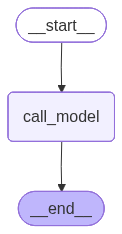

In [9]:
graph_with_memory


In [ ]:
# 정답 코드
# TODO: InMemorySaver/Store로 그래프 컴파일 및 노드/엣지 구성
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.store.memory import InMemoryStore

memory_saver = InMemorySaver()
memory_store = InMemoryStore()

builder.add_node("call_model", call_model)
builder.add_edge(START, "call_model")

graph_with_memory = builder.compile(checkpointer=memory_saver, store=memory_store)

NameError: name 'builder' is not defined

### 5) 시나리오 실행 1: 개인정보 등록 + remember

아래 예시는 최초 상담에서 고객이 자신의 정보를 제공하며 `remember` 를 명시하는 경우입니다. 동일한 `user_id` 와 `thread_id` 를 전달하세요.

요구사항
- `RunnableConfig` 의 `configurable`에 `thread_id`, `user_id`를 설정하세요.
- "제 이름은 홍길동이고, 계좌번호는 110-123-456789 입니다. remember" 와 같은 문장을 입력하여 메모리 저장을 유도하세요.
- `stream_graph` 로 실행 결과를 확인하세요.


In [ ]:
# 실습 코드
# TODO: 동일 thread_id/user_id로 개인정보 + remember 시나리오 실행
from langchain_teddynote.messages import stream_graph
from langchain_core.runnables import RunnableConfig

config1 = RunnableConfig(
    configurable={"thread_id": "t-001user-abc", "user_id": "user-abc"}
)
inputs1 = {
    "messages": [
        {
            "role": "user",
            "content": "제 이름은 홍길동이고, 계좌번호는 110-123-456789 입니다. remember",
        }
    ]
}

# 코드 입력 (stream_graph 로 실행)

### 6) 시나리오 실행 2: 다른 thread에서 동일 user로 재상담

이제 thread만 바꿔 동일한 `user_id`로 다시 질문합니다. 챗봇은 기존 메모리를 바탕으로 불필요한 개인정보 재질문 없이 바로 답변해야 합니다.

요구사항
- `thread_id`만 변경하고, `user_id`는 동일하게 유지하세요.
- "어제 안내해준 대출 상환 스케줄 다시 알려줘" 같은 문장을 사용해 답변을 확인하세요.


In [ ]:
# 실습 코드
# TODO: 다른 thread_id, 같은 user_id로 실행하여 메모리 활용 확인
from langchain_core.runnables import RunnableConfig
from langchain_teddynote.messages import stream_graph

config2 = RunnableConfig(
    configurable={"thread_id": "t-002user-abc", "user_id": "user-abc"}
)
inputs2 = {"messages": [{"role": "user", "content": "제 정보를 알려주세요"}]}

stream_graph(graph_with_memory, inputs=inputs2, config=config2)